# 1. ENVIROMENT SET UP

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

import sys
import os

sys.path.append(os.path.abspath(".."))

# 2. DATA UNDERSTANDING

In [42]:
from src.data_loader import load_and_merge_data

df, water_quality, landsat, terraclimate = load_and_merge_data()

df.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,month,year,dayofyear,nir,green,swir16,swir22,NDMI,MNDWI,pet
0,-28.760833,17.730278,2011-01-02,128.912,555.0,10.0,1,2011,2,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,174.2
1,-26.861111,28.884722,2011-01-03,74.720,162.9,163.0,1,2011,3,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,124.1
2,-26.450000,28.085833,2011-01-03,89.254,573.0,80.0,1,2011,3,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,127.5
3,-27.671111,27.236944,2011-01-03,82.000,203.6,101.0,1,2011,3,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,129.7
4,-27.356667,27.286389,2011-01-03,56.100,145.1,151.0,1,2011,3,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,129.2


In [43]:
print("Water quality shape:", water_quality.shape)
print("Landsat shape:", landsat.shape)
print("Terraclimate shape:", terraclimate.shape)

Water quality shape: (9319, 9)
Landsat shape: (9319, 9)
Terraclimate shape: (9319, 4)


In [44]:
water_quality.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,month,year,dayofyear
0,-28.760833,17.730278,2011-01-02,128.912,555.0,10.0,1,2011,2
1,-26.861111,28.884722,2011-01-03,74.720,162.9,163.0,1,2011,3
2,-26.450000,28.085833,2011-01-03,89.254,573.0,80.0,1,2011,3
3,-27.671111,27.236944,2011-01-03,82.000,203.6,101.0,1,2011,3
4,-27.356667,27.286389,2011-01-03,56.100,145.1,151.0,1,2011,3


In [45]:
landsat.head()

,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI
0,-28.760833,17.730278,2011-01-02,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,2011-01-03,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,2011-01-03,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,2011-01-03,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,2011-01-03,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


In [46]:
terraclimate.head()

,Latitude,Longitude,Sample Date,pet
0,-28.760833,17.730278,2011-01-02,174.2
1,-26.861111,28.884722,2011-01-03,124.1
2,-26.450000,28.085833,2011-01-03,127.5
3,-27.671111,27.236944,2011-01-03,129.7
4,-27.356667,27.286389,2011-01-03,129.2


In [47]:
water_quality.info()
landsat.info()
terraclimate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Latitude                       9319 non-null   float64       
 1   Longitude                      9319 non-null   float64       
 2   Sample Date                    9319 non-null   datetime64[ns]
 3   Total Alkalinity               9319 non-null   float64       
 4   Electrical Conductance         9319 non-null   float64       
 5   Dissolved Reactive Phosphorus  9319 non-null   float64       
 6   month                          9319 non-null   int32         
 7   year                           9319 non-null   int32         
 8   dayofyear                      9319 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3)
memory usage: 546.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns

In [48]:
water_quality.isna().sum()

Latitude                         0
Longitude                        0
Sample Date                      0
Total Alkalinity                 0
Electrical Conductance           0
Dissolved Reactive Phosphorus    0
month                            0
year                             0
dayofyear                        0
dtype: int64

In [49]:
landsat.isna().sum()

Latitude          0
Longitude         0
Sample Date       0
nir            1085
green          1085
swir16         1085
swir22         1085
NDMI           1085
MNDWI          1085
dtype: int64

In [50]:
terraclimate.isna().sum()

Latitude       0
Longitude      0
Sample Date    0
pet            0
dtype: int64

In [51]:
water_quality["Sample Date"] = pd.to_datetime(water_quality["Sample Date"], dayfirst=True)
landsat["Sample Date"] = pd.to_datetime(landsat["Sample Date"], dayfirst=True)
terraclimate["Sample Date"] = pd.to_datetime(terraclimate["Sample Date"], dayfirst=True)

In [52]:
water_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Latitude                       9319 non-null   float64       
 1   Longitude                      9319 non-null   float64       
 2   Sample Date                    9319 non-null   datetime64[ns]
 3   Total Alkalinity               9319 non-null   float64       
 4   Electrical Conductance         9319 non-null   float64       
 5   Dissolved Reactive Phosphorus  9319 non-null   float64       
 6   month                          9319 non-null   int32         
 7   year                           9319 non-null   int32         
 8   dayofyear                      9319 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3)
memory usage: 546.2 KB


In [53]:
water_quality["month"] = water_quality["Sample Date"].dt.month
water_quality["year"] = water_quality["Sample Date"].dt.year
water_quality["dayofyear"] = water_quality["Sample Date"].dt.dayofyear

In [54]:
water_quality.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,month,year,dayofyear
0,-28.760833,17.730278,2011-01-02,128.912,555.0,10.0,1,2011,2
1,-26.861111,28.884722,2011-01-03,74.720,162.9,163.0,1,2011,3
2,-26.450000,28.085833,2011-01-03,89.254,573.0,80.0,1,2011,3
3,-27.671111,27.236944,2011-01-03,82.000,203.6,101.0,1,2011,3
4,-27.356667,27.286389,2011-01-03,56.100,145.1,151.0,1,2011,3


In [55]:
water_quality["Sample Date"].min()


Timestamp('2011-01-02 00:00:00')

In [56]:
water_quality["Sample Date"].max()

Timestamp('2015-12-31 00:00:00')

In [57]:
print(landsat.duplicated().sum())
print(terraclimate.duplicated().sum())
print(water_quality.duplicated().sum())

0
0
0


In [58]:
water_quality.duplicated(
    subset=["Latitude","Longitude","Sample Date"]
).sum()

np.int64(0)

# 3. DATA MERGING

In [59]:
df = water_quality.merge(
    landsat,
    on=["Latitude", "Longitude", "Sample Date"],
    how="left"
)

df = df.merge(
    terraclimate,
    on=["Latitude", "Longitude", "Sample Date"],
    how="left"
)
df.shape

(9319, 16)

In [60]:
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Latitude                       9319 non-null   float64       
 1   Longitude                      9319 non-null   float64       
 2   Sample Date                    9319 non-null   datetime64[ns]
 3   Total Alkalinity               9319 non-null   float64       
 4   Electrical Conductance         9319 non-null   float64       
 5   Dissolved Reactive Phosphorus  9319 non-null   float64       
 6   month                          9319 non-null   int32         
 7   year                           9319 non-null   int32         
 8   dayofyear                      9319 non-null   int32         
 9   nir                            8234 non-null   float64       
 10  green                          8234 non-null   float64       
 11  swir16           

Latitude                            0
Longitude                           0
Sample Date                         0
Total Alkalinity                    0
Electrical Conductance              0
Dissolved Reactive Phosphorus       0
month                               0
year                                0
dayofyear                           0
nir                              1085
green                            1085
swir16                           1085
swir22                           1085
NDMI                             1085
MNDWI                            1085
pet                                 0
dtype: int64

# 4. Exploratory Data Analysis (EDA)

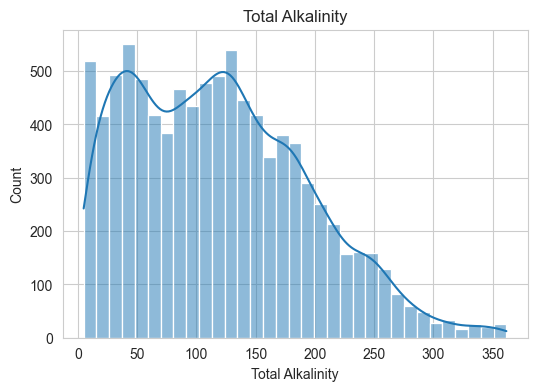

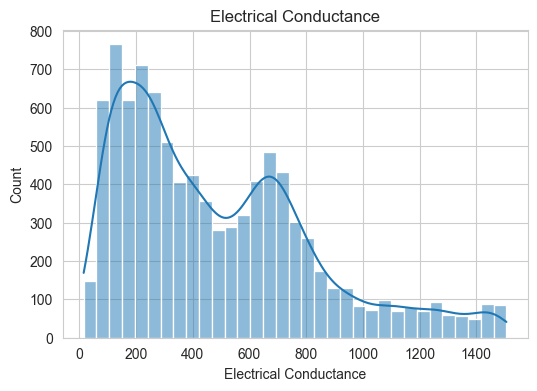

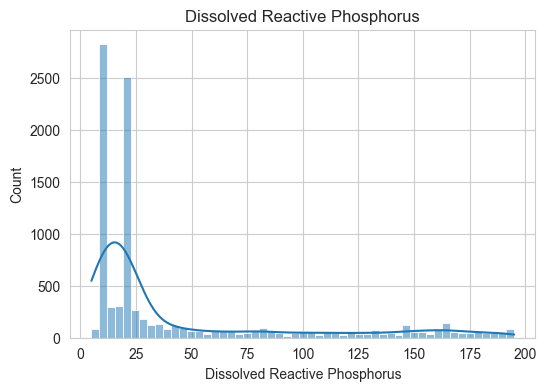

In [61]:
targets = [
    "Total Alkalinity",
    "Electrical Conductance",
    "Dissolved Reactive Phosphorus"
]

for col in targets:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

The distributions of the three target variables show noticeable right-skewness, particularly for Electrical Conductance and Dissolved Reactive Phosphorus, which exhibit long tails with some high-value outliers. Total Alkalinity presents a more moderate skew with most observations concentrated between lower and mid ranges. These patterns suggest that the dataset contains natural variability typical of environmental measurements. Tree-based models such as Random Forest or Gradient Boosting are suitable for this problem since they can handle non-normal distributions and outliers without requiring transformation of the target variables.

## CORR

#### CORRRELACION ENTRE VARIABLES

Objetivo: detectar qué features están relacionadas con los targets. 
Para ver qué features están relacionadas con los targets.
Si una variable (ej. NDMI o pet) tiene correlación con un target, significa que puede ayudar al modelo a predecirlo.

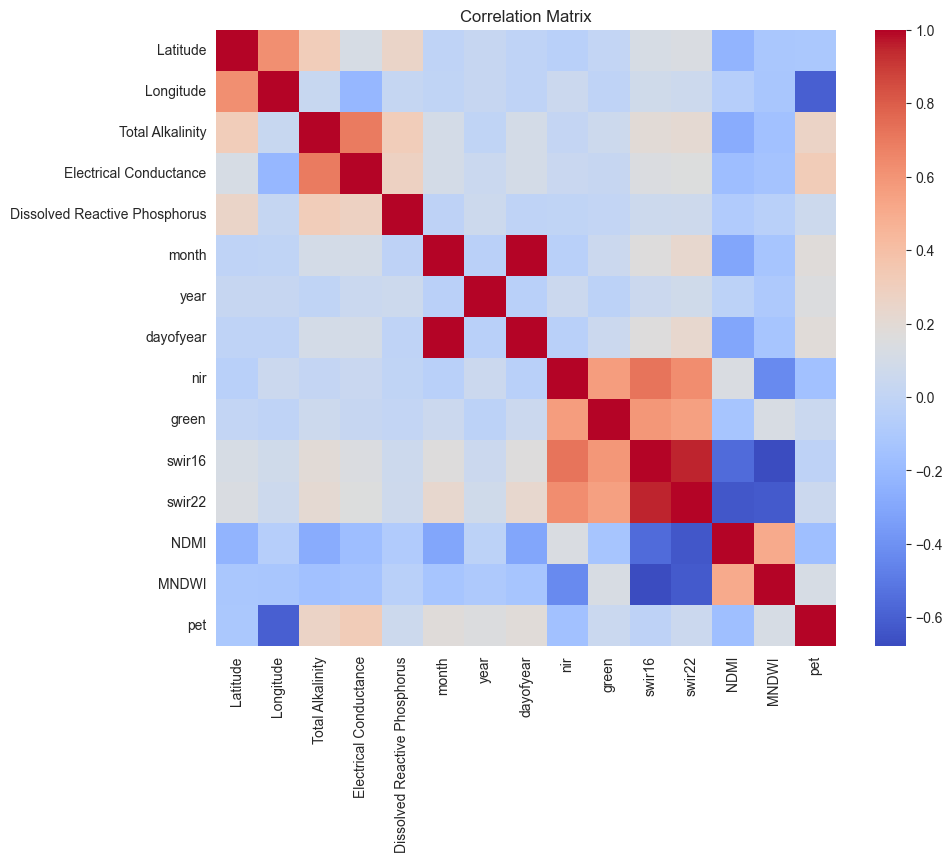

In [62]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### SCATTER PLOTS FEATURE VS TARGET

Objetivo: ver relaciones no lineales que el modelo puede aprender. Aunque la correlación sea baja, el gráfico puede mostrar patrones no lineales que los modelos de árboles sí pueden aprender.

<Axes: xlabel='NDMI', ylabel='Electrical Conductance'>

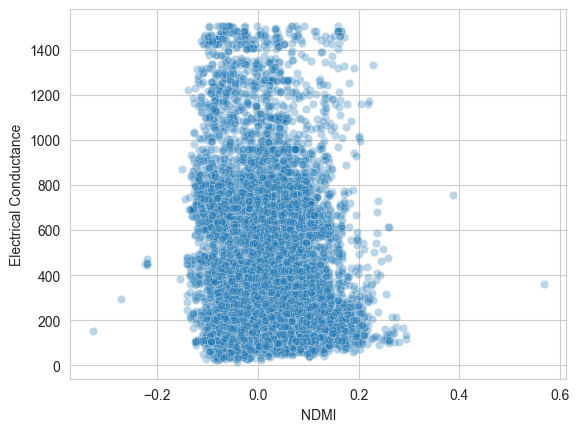

In [63]:
sns.scatterplot(x="NDMI", y="Electrical Conductance", data=df, alpha=0.3)

<Axes: xlabel='pet', ylabel='Electrical Conductance'>

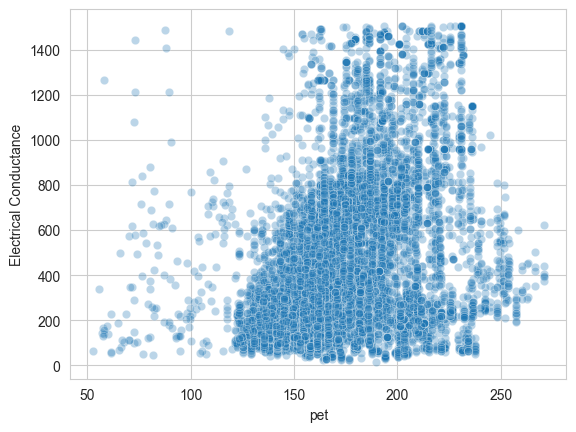

In [64]:
sns.scatterplot(x="pet", y="Electrical Conductance", data=df, alpha=0.3)

<Axes: xlabel='MNDWI', ylabel='Dissolved Reactive Phosphorus'>

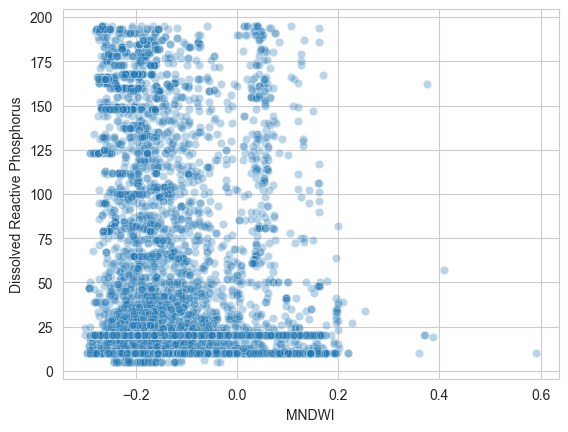

In [65]:
sns.scatterplot(x="MNDWI", y="Dissolved Reactive Phosphorus", data=df, alpha=0.3)

#### VISUALIZACION ESPACIAL

Objetivo: ver si hay clusters geográficos. Para ver cómo están distribuidos los puntos en el mapa.
Sirve para detectar clusters geográficos, lo que sugiere que la ubicación puede influir en la calidad del agua.

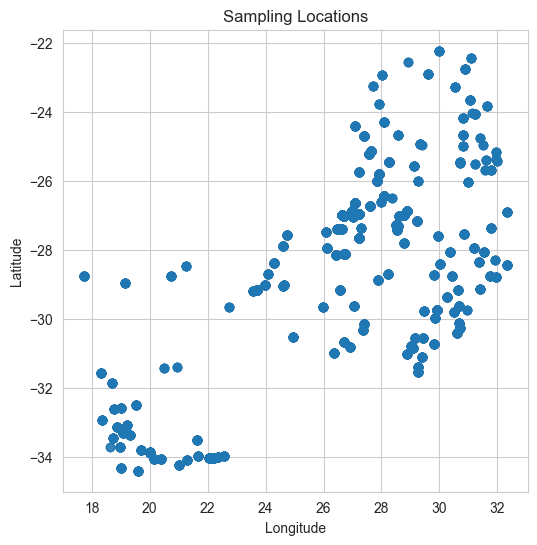

In [66]:
plt.figure(figsize=(6,6))
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sampling Locations")
plt.show()

df_model.fillna(df_model.median(numeric_only=True), inplace=True)

# 5. DATA CLEANING

Los modelos no pueden tener valores na, hay que rellenar y relleo con la media.

In [67]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.isna().sum()

Latitude                         0
Longitude                        0
Sample Date                      0
Total Alkalinity                 0
Electrical Conductance           0
Dissolved Reactive Phosphorus    0
month                            0
year                             0
dayofyear                        0
nir                              0
green                            0
swir16                           0
swir22                           0
NDMI                             0
MNDWI                            0
pet                              0
dtype: int64

In [72]:
import pandas as pd

pd.set_option("display.max_rows", None)

df = pd.read_csv("../data/water_quality_training_dataset.csv")

site_counts = df.groupby(["Latitude","Longitude"]).size()

print(site_counts.describe())


count    162.000000
mean      57.524691
std       40.214981
min        6.000000
25%       32.250000
50%       50.000000
75%       64.000000
max      210.000000
dtype: float64


In [73]:
site_counts = df.groupby(["Latitude","Longitude"]).size()

counts_list = site_counts.value_counts().sort_index().tolist()

print(counts_list)

[1, 2, 1, 1, 2, 1, 1, 1, 4, 2, 1, 1, 3, 2, 3, 1, 1, 1, 1, 3, 1, 2, 1, 2, 2, 1, 2, 3, 2, 2, 1, 1, 3, 1, 3, 4, 2, 2, 1, 1, 7, 5, 4, 8, 2, 5, 5, 2, 6, 2, 1, 2, 3, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]
